
### **Benefit of BatchNorm with CIFAR10 Classification**


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import utils
from numpy import mean, std

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = (X_train.astype('float32')- mean(X_train)) / std(X_train)
X_test = (X_test.astype('float32')-mean(X_test))/ std(X_test)


##### a) **Implement a miwed CNN/ML architecture**
Use 3 conv and 2 fully connected hidden layers, ReLU for classifying CIFAR10 without batchnorm layers not regularisation.
Ex : Conv2d -> ReLU -> MaxPool -> Conv2d -> ReLU -> MaxPool -> Linear -> ReLU -> Linear (+ possibliy softmax)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,714 (2.11 MB)

 Trainable params: 552,714 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

##### b) **Train over a suitable number of epochs**
Until we can see a stable test performance or before overfitting. Use Adam with defaults settings

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
          epochs=20,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5192 - loss: 1.3517 - val_accuracy: 0.6158 - val_loss: 1.1025
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6669 - loss: 0.9502 - val_accuracy: 0.6826 - val_loss: 0.9169
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7225 - loss: 0.7914 - val_accuracy: 0.7170 - val_loss: 0.8331
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7682 - loss: 0.6684 - val_accuracy: 0.7290 - val_loss: 0.8101
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8029 - loss: 0.5622 - val_accuracy: 0.7328 - val_loss: 0.8224
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8386 - loss: 0.4656 - val_accuracy: 0.7164 - val_loss: 0.8818
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8678 - loss: 0.3785 - val_accuracy: 0.7028 - val_loss: 0.9598
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8946 - loss: 0.2989 - val_accuracy: 

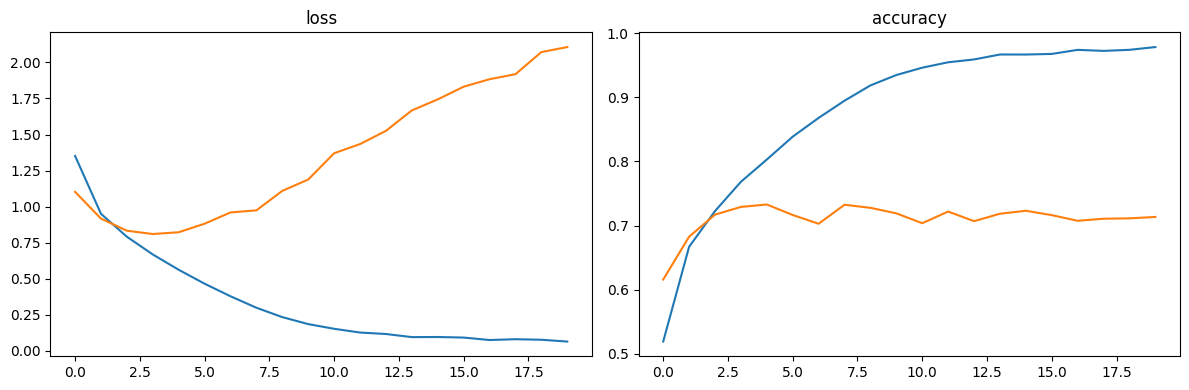

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title("accuracy")
plt.tight_layout()
plt.show()

With 20 epochs, we can clearly see that the model begins overfitting while the test performance becomes stablilizes or decreases. 10 epochs are enough.

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])



In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5201 - loss: 1.3457 - val_accuracy: 0.6214 - val_loss: 1.0577
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6662 - loss: 0.9465 - val_accuracy: 0.6848 - val_loss: 0.9094
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7251 - loss: 0.7862 - val_accuracy: 0.7086 - val_loss: 0.8547
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7658 - loss: 0.6711 - val_accuracy: 0.7206 - val_loss: 0.8295
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8008 - loss: 0.5656 - val_accuracy: 0.7074 - val_loss: 0.8923
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8332 - loss: 0.4749 - val_accuracy: 0.7300 - val_loss: 0.8609
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8637 - loss: 0.3872 - val_accuracy: 0.7162 - val_loss: 0.9797
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8876 - loss: 0.3168 - val_accuracy: 0.

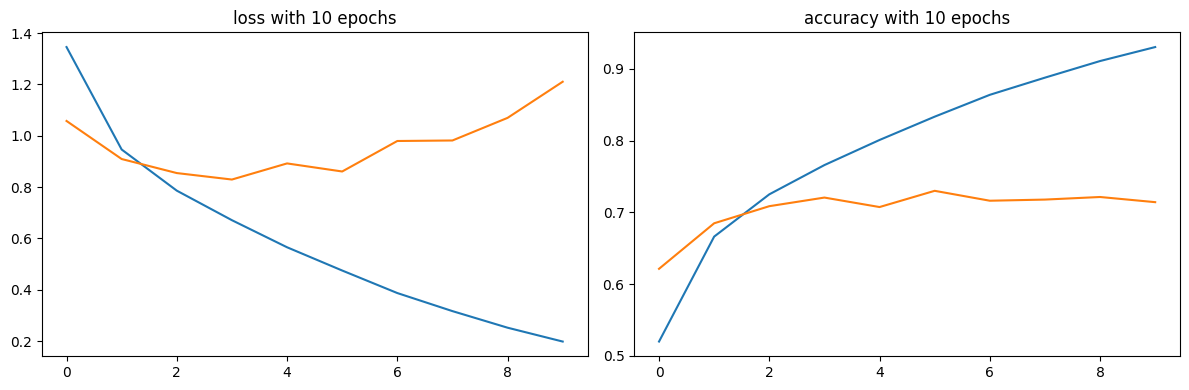

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss with 10 epochs')
ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title("accuracy with 10 epochs")
plt.tight_layout()
plt.show()

The blue line corresponds to the test and the orange one to the validation. We obtain a test accuracy of **69.55%**.

##### c) **Use Tanh instead of ReLU**

In [ ]:
from tensorflow.keras import layers, models

model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='tanh', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3,3), activation='tanh', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(10, activation='softmax')
])


model2.summary()

model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss2, test_acc2 = model2.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc2:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,714 (2.11 MB)

 Trainable params: 552,714 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5424 - loss: 1.2927 - val_accuracy: 0.6364 - val_loss: 1.0332
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6719 - loss: 0.9426 - val_accuracy: 0.6606 - val_loss: 0.9652
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7285 - loss: 0.7791 - val_accuracy: 0.6858 - val_loss: 0.9088
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7779 - loss: 0.6476 - val_accuracy: 0.6826 - val_loss: 0.9307
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8214 - loss: 0.5260 - val_accuracy: 0.6790 - val_loss: 0.9598
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8588 - loss: 0.4172 - val_accuracy: 0.6808 - val_loss: 1.0011
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8916 - loss: 0.3259 - val_accuracy: 0.6734 - val_loss: 1.1311
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9218 - loss: 0.2403 - val_accuracy: 0.


We obtain a test accuracy of **67.25%**. à vérifier

##### d) **Add batchnorm after each Conv2d and Linear layer**
- 1. With ReLU

In [ ]:
model3 = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])


model3.summary()

model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history3 = model3.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss3, test_acc3 = model3.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc3:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,866 (2.11 MB)

 Trainable params: 553,290 (2.11 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5738 - loss: 1.2053 - val_accuracy: 0.6022 - val_loss: 1.1339
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7043 - loss: 0.8458 - val_accuracy: 0.6630 - val_loss: 0.9649
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7606 - loss: 0.6843 - val_accuracy: 0.7316 - val_loss: 0.8056
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8047 - loss: 0.5580 - val_accuracy: 0.6962 - val_loss: 0.9508
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8468 - loss: 0.4414 - val_accuracy: 0.7186 - val_loss: 0.8918
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8788 - loss: 0.3543 - val_accuracy: 0.7208 - val_loss: 0.9303
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9078 - loss: 0.2663 - val_accuracy: 0.7082 - val_loss: 1.0361
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9272 - loss: 0.2125 - val_accuracy:

We obtain a test accuracy of **71.23%**.

- 2. With Tanh

In [ ]:
model4 = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('tanh'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('tanh'),

    layers.Dense(10, activation='softmax')
])

model4.summary()

model4.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history4 = model4.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss4, test_acc4 = model4.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc4:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,866 (2.11 MB)

 Trainable params: 553,290 (2.11 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5235 - loss: 1.3526 - val_accuracy: 0.5834 - val_loss: 1.1707
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6471 - loss: 1.0123 - val_accuracy: 0.6594 - val_loss: 0.9797
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6997 - loss: 0.8605 - val_accuracy: 0.6750 - val_loss: 0.9281
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7394 - loss: 0.7554 - val_accuracy: 0.6538 - val_loss: 1.0068
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7727 - loss: 0.6525 - val_accuracy: 0.6934 - val_loss: 0.9114
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8072 - loss: 0.5588 - val_accuracy: 0.6908 - val_loss: 0.9256
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8406 - loss: 0.4666 - val_accuracy: 0.6790 - val_loss: 0.9902
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8684 - loss: 0.3850 - val_accuracy: 

We obtain a test accuracy of **66.78%**.

##### e) **Add dropout before each fully connected layer (not CNN)**
We will try with 30% of dropout.
- 1. With batchnorm

In [ ]:

model5 = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dropout(0.3),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')#pas de dropout avant ici parce que sinon ca injecte du bruit dans la solution finale
])


In [ ]:


model5.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history5 = model5.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss5, test_acc5 = model5.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc5:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5001 - loss: 1.3919 - val_accuracy: 0.6216 - val_loss: 1.0681
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6244 - loss: 1.0556 - val_accuracy: 0.6802 - val_loss: 0.9169
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6656 - loss: 0.9430 - val_accuracy: 0.6862 - val_loss: 0.8821
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6917 - loss: 0.8717 - val_accuracy: 0.7060 - val_loss: 0.8289
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7129 - loss: 0.8110 - val_accuracy: 0.7370 - val_loss: 0.7712
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7351 - loss: 0.7528 - val_accuracy: 0.7502 - val_loss: 0.7311
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7497 - loss: 0.7099 - val_accuracy: 0.7532 - val_loss: 0.7175
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7580 - loss: 0.6730 - val_accuracy: 

We obtain a test accuracy of **75.93%**.

- 2. Without batchnorm

In [ ]:
model6 = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)),
    #layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), padding='same'),
    #layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dropout(0.3),
    layers.Dense(128),
    #layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dropout(0.3),
    layers.Dense(64),
    #layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])
model6.summary()

model6.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history6 = model6.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss6, test_acc6 = model6.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc6:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,714 (2.11 MB)

 Trainable params: 552,714 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4474 - loss: 1.5206 - val_accuracy: 0.5804 - val_loss: 1.1661
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5921 - loss: 1.1491 - val_accuracy: 0.6444 - val_loss: 1.0351
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6389 - loss: 1.0194 - val_accuracy: 0.6932 - val_loss: 0.8870
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6703 - loss: 0.9309 - val_accuracy: 0.6988 - val_loss: 0.8608
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6965 - loss: 0.8701 - val_accuracy: 0.7012 - val_loss: 0.8624
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7108 - loss: 0.8163 - val_accuracy: 0.7124 - val_loss: 0.8193
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7270 - loss: 0.7698 - val_accuracy: 0.7350 - val_loss: 0.7672
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7426 - loss: 0.7330 - val_accuracy: 

We obtain a test accuracy of **73.92%**.

- How far can we up the test accuracy by continuing the training possibly over more epochs?

We can test to train the model with dropout and batchnorm over 20 epochs :

In [ ]:

model5_test = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dropout(0.3),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')#pas de dropout avant ici parce que sinon ca injecte du bruit dans la solution finale
])

model5_test.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history5_20ep = model5_test.fit(X_train, y_train,
          epochs=20,
          batch_size=64,
          validation_split=0.1,
          verbose = 1)

test_loss5_20ep, test_acc5_20ep = model5.evaluate(X_test, y_test)
print(f"\nAccuracy : {test_acc5_20ep:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5139 - loss: 1.3608 - val_accuracy: 0.5936 - val_loss: 1.1497
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6319 - loss: 1.0446 - val_accuracy: 0.6734 - val_loss: 0.9209
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6688 - loss: 0.9376 - val_accuracy: 0.7100 - val_loss: 0.8580
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6963 - loss: 0.8602 - val_accuracy: 0.7300 - val_loss: 0.7848
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7166 - loss: 0.8046 - val_accuracy: 0.7424 - val_loss: 0.7395
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7378 - loss: 0.7510 - val_accuracy: 0.7556 - val_loss: 0.7032
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7492 - loss: 0.7070 - val_accuracy: 0.7488 - val_loss: 0.7247
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7616 - loss: 0.6743 - val_accuracy: 

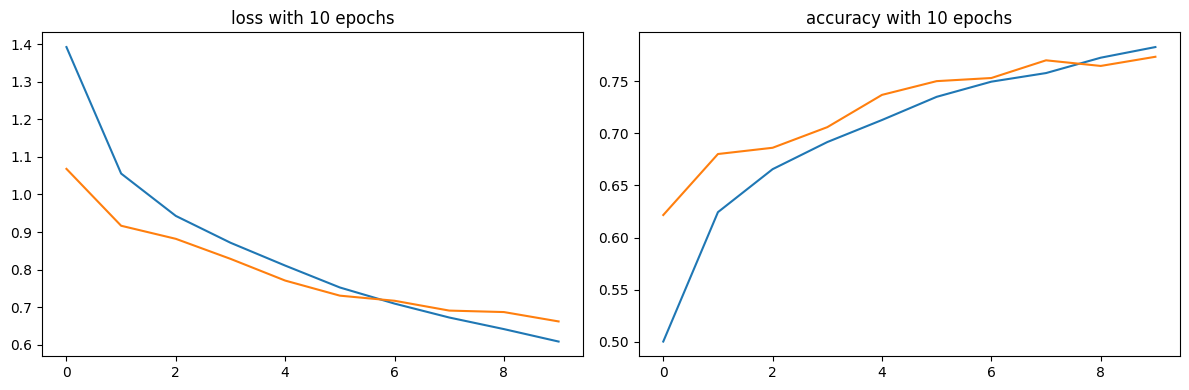

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history5.history['loss'],     label='train')
ax1.plot(history5.history['val_loss'], label='val')
ax1.set_title('loss with 10 epochs')
ax2.plot(history5.history['accuracy'],     label='train')
ax2.plot(history5.history['val_accuracy'], label='val')
ax2.set_title("accuracy with 10 epochs")
plt.tight_layout()
plt.show()

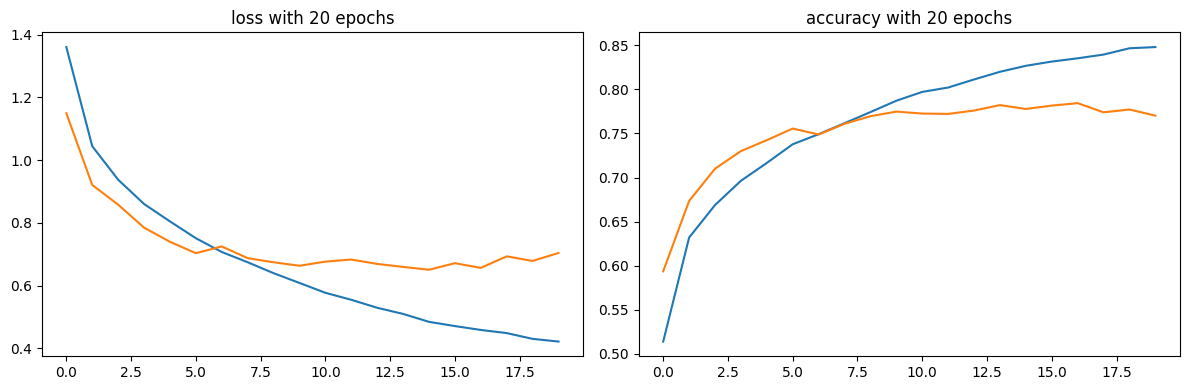

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history5_20ep.history['loss'],     label='train')
ax1.plot(history5_20ep.history['val_loss'], label='val')
ax1.set_title('loss with 20 epochs')
ax2.plot(history5_20ep.history['accuracy'],     label='train')
ax2.plot(history5_20ep.history['val_accuracy'], label='val')
ax2.set_title("accuracy with 20 epochs")
plt.tight_layout()
plt.show()

We can see on the previous curves that increasing the number of epochs shows us the convergence of the test accuracy. However, the learning process stays unstable. A clear overfitting is visible due to the gap between the train and the test curves.

##### f) **Comparisons plot**
- 1. With batchnorm -> <span style='color: orange;'>model3 with relu</span> and <span style='color: greenyellow;'>model4 with tanh</span>
- 3. without batchnorm -> <span style='color: violet;'>model with relu</span> and <span style='color: purple;'>model2 with tanh</span>
- 4. With dropout regularisation -> <span style='color: lightpink;'>model6 with relu</span>
- 5. With dropout and batchnorm -> <span style='color: pink;'>model5 with relu</span>

Estimate a factor of speedup when using batchnorm (with/without reg, with ReLU or Tanh).



Make a statement about whether the results are as we expect.

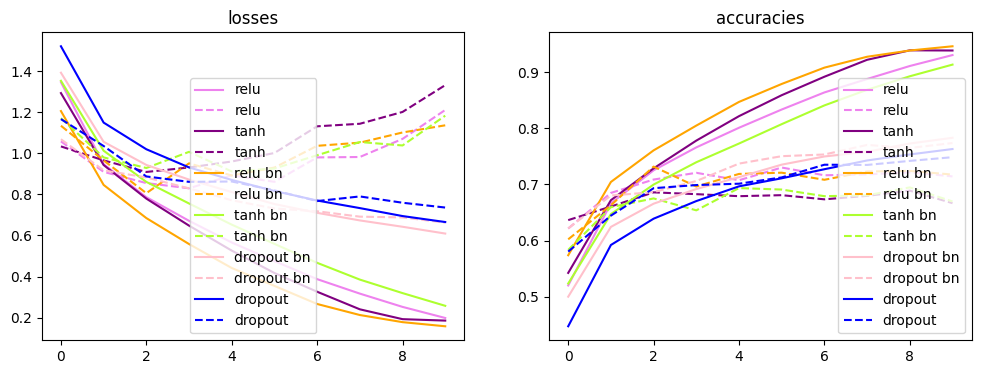

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='relu', linestyle = '-', c = 'violet')
ax1.plot(history.history['val_loss'], label='relu', linestyle = '--', c = 'violet')
ax1.plot(history2.history['loss'],     label='tanh',linestyle = '-', c = 'purple')
ax1.plot(history2.history['val_loss'], label='tanh', linestyle = '--', c= 'purple')
ax1.plot(history3.history['loss'],     label='relu bn',linestyle = '-', c = 'orange')
ax1.plot(history3.history['val_loss'], label='relu bn', linestyle = '--', c = 'orange')
ax1.plot(history4.history['loss'],     label='tanh bn', linestyle = '-', c = 'greenyellow')
ax1.plot(history4.history['val_loss'], label='tanh bn', linestyle = '--', c = 'greenyellow')
ax1.plot(history5.history['loss'],     label='dropout bn', linestyle = '-', c = 'pink')
ax1.plot(history5.history['val_loss'], label='dropout bn', linestyle = '--', c = 'pink')
ax1.plot(history6.history['loss'],     label='dropout', linestyle = '-', c = 'blue')
ax1.plot(history6.history['val_loss'], label='dropout', linestyle = '--', c = 'blue')
ax1.legend()
ax1.set_title('losses')

ax2.plot(history.history['accuracy'],     label='relu', linestyle = '-', c = 'violet')
ax2.plot(history.history['val_accuracy'], label='relu', linestyle = '--', c = 'violet')
ax2.plot(history2.history['accuracy'],     label='tanh',linestyle = '-', c = 'purple')
ax2.plot(history2.history['val_accuracy'], label='tanh', linestyle = '--', c= 'purple')
ax2.plot(history3.history['accuracy'],     label='relu bn',linestyle = '-', c = 'orange')
ax2.plot(history3.history['val_accuracy'], label='relu bn', linestyle = '--', c = 'orange')
ax2.plot(history4.history['accuracy'],     label='tanh bn', linestyle = '-', c = 'greenyellow')
ax2.plot(history4.history['val_accuracy'], label='tanh bn', linestyle = '--', c = 'greenyellow')
ax2.plot(history5.history['accuracy'],     label='dropout bn', linestyle = '-', c = 'pink')
ax2.plot(history5.history['val_accuracy'], label='dropout bn', linestyle = '--', c = 'pink')
ax2.plot(history6.history['accuracy'],     label='dropout', linestyle = '-', c = 'blue')
ax2.plot(history6.history['val_accuracy'], label='dropout', linestyle = '--', c = 'blue')
ax2.legend()
ax2.set_title("accuracies")
plt.show()

- <span style='color: pink;'>relu</span> : Converges and reaches ~95% validation accuracy with low final loss.

- <span style='color: purple;'>tanh</span> : Similar to ReLU but slightly slower to convergence.

- <span style='color: orange;'>relu with bn</span> : Fastest convergence with a loss which drops fastly. It's seems to be our best model.

- <span style='color: lightgreen;'>tanh with bn</span> : Fast convergence but  underperforms the model with relu and batchnorm at the end.

- <span style='color: blue;'>relu with dropout</span> : Slower convergence and lower final accuracy. The heavy regularization from dropout without batchnorm doesn't allow a good learning. The dropout rate is maybe too high. However, the train/val gap is nealry inexistant, indicating no overfitting.

- <span style='color: blue;'>relu with dropout and bn</span> : Slightly better than dropout only, but still achieve lower performances. Batchnorm tries to compensate for dropout's destabilizing effect, but final accuracy remains limited low. There is no overfitting though.


We can estimate a factore of speedup when using batchnorm by comparing relu with relu and bn on the accuracy curves with the objectif of an accuracy of 70%:
- It's not very clear to see but relu seems to reach this goal at the epoch 2.
- relu and bn reaches 70% accuracy during epoch 1.

This suggests a speedup factor of approximatly ×2 in terms of epochs needed to reach the same performance level.

Batch normalization seems to be the most impactful technique in this experiment : it accelerate the convergence while maintaining strong final performance. Dropout alone avoid good performance. The best strategy is using relu with batchnormalisation, according to our observations.